In [1]:
# Install sklearn
!pip install scikit-learn==1.5.2

# Install TabPFN API Client
!pip install tabpfn-client

# TabPFN Extensions installs optional functionalities around the TabPFN model
# These include post-hoc ensembles, interpretability tools, and more
!git clone https://github.com/PriorLabs/tabpfn-extensions
!pip install -e tabpfn-extensions
!pip install tabpfn # TabPFN, currently required by tabpfn-extensions, but not basic usage


# Install Baselines
!pip install catboost xgboost

# Install example datasets
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 90.0 MB/s eta 0:00:00
Cloning into 'tabpfn-extensions'...
remote: Enumerating objects: 2089, done.
remote: Counting objects: 100% (293/293), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 2089 (delta 213), reused 181 (delta 181), pack-reused 1796 (from 2)
Receiving objects: 100% (2089/2089), 776.64 KiB | 21.57 MiB/s, done.
Resolving deltas: 100% (1273/1273), done.
Obtaining file:///content/tabpfn-extensions
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128

In [2]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 4.1 MB/s eta 0:00:00


In [ ]:
#pip install nanopq

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from tabpfn import TabPFNClassifier

In [4]:
# Load data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7126,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7128,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
#f, t, p = JMI.jmi(X_train,y_train, n_selected_features = 5)
f = JMI.jmi(X_train, y_train, n_selected_features=100 )
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 72.02252864837646 sec


In [ ]:
f

array([41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1])

In [ ]:
len(f)

100

In [5]:
f = [41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1]

In [6]:
f = np.array(f)
f

array([41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1])

In [7]:
len(f)

100

In [ ]:
f[0:100]

array([41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1])

In [8]:
selected_features_names=[]
for i in range(len(f[0:100])):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['BIND_VPN_SERVICE',
 'BIND_APPWIDGET',
 'BIND_CARRIER_MESSAGING_SERVICE',
 'BRICK',
 'DELETE_CACHE_FILES',
 'ANT',
 'BIND_PRINT_SERVICE',
 'CLEAR_APP_CACHE',
 'DELETE_PACKAGES',
 'ACCESS_LOCATION_EXTRA_COMMANDS',
 'ACCOUNT_MANAGER',
 'BLUETOOTH_PRIVILEGED',
 'ANT_ADMIN',
 'DOWNLOAD_WITHOUT_goodwareTIFICATION',
 'FULLSCREEN.FULL',
 'ACCESS_SUPERUSER',
 'GET_TASKS',
 'ACCESS_COARSE_UPDATES',
 'CALL_PHONE',
 'C2D_MESSAGE',
 'ACCESS_SURFACE_FLINGER',
 'BLUETOOTH_ADMIN',
 'DUMP',
 'DEVICE_POWER',
 'BODY_SENSORS',
 'INTERNAL_SYSTEM_WINDOW',
 'AUTORUN_MANAGER_LICENSE_SERVICE(.autorun)',
 'GLOBAL_SEARCH',
 'ACCESS_SERVICE',
 'HARDWARE_TEST',
 'INSTALL_LOCATION_PROVIDER',
 'activityCalled',
 'FORCE_BACK',
 'BIND_VOICE_INTERACTION',
 'EXPAND_STATUS_BAR',
 'CHANGE_WIFI_MULTICAST_STATE',
 'CLEAR_APP_USER_DATA',
 'BROADCAST_STICKY',
 'BIND_ACCESSIBILITY_SERVICE',
 'AUTORUN_MANAGER_LICENSE_MANAGER',
 'CALL_PRIVILEGED',
 'EXTENSION_PERMISSION',
 'BROADCAST_WAP_PUSH',
 'GET_ACCOUNTS',
 'BIND_WALLPAPE

In [9]:
len(selected_features_names)

100

In [ ]:
from tabpfn import TabPFNClassifier

tab_pfn_={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
for i in range(2,len(selected_features_names)+1):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    #start = time.time()
    #pq_pq = PQ(M=int(i/2), Ks=2)
    #pq_pq.fit(X.astype(np.float32))
    #codes_pq = pq_pq.encode(X.astype(np.float32))
    #end = time.time()

    # print the difference between start
    # and end time in milli. secs
    #print("The time of execution of above program is :", (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
    # Initialize a classifier
    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    tab_pfn_["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_["acc"]['index'].append(i)
    tab_pfn_["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_["per"]['index'].append(i)
    tab_pfn_["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_["rec"]['index'].append(i)
    tab_pfn_["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_["f1s"]['index'].append(i)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_["auc"]['index'].append(i)

/usr/local/lib/python3.11/dist-packages/tabpfn/base.py:89: UserWarning: Downloading model to /root/.cache/tabpfn/tabpfn-v2-classifier.ckpt.
  model, _, config_ = load_model_criterion_config(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v2-classifier.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

The time of execution of training the tabpfn is : 204.17178916931152 sec
The time of execution of testing sample with the tabpfn is : 0.0033269431781635045 sec
The time of execution of training the tabpfn is : 203.85079836845398 sec
The time of execution of testing sample with the tabpfn is : 0.0007993780379542796 sec
The time of execution of training the tabpfn is : 211.41233205795288 sec
The time of execution of testing sample with the tabpfn is : 0.0009360883546912152 sec
The time of execution of training the tabpfn is : 209.30135679244995 sec
The time of execution of testing sample with the tabpfn is : 0.0009529904931323893 sec
The time of execution of training the tabpfn is : 219.95308423042297 sec
The time of execution of testing sample with the tabpfn is : 0.0009460353918195941 sec
The time of execution of training the tabpfn is : 212.84149503707886 sec
The time of execution of testing sample with the tabpfn is : 0.0011057873762005007 sec
The time of execution of training the ta

In [ ]:
print("the highest accuracy where the number of features is: ", tab_pfn_["acc"]['index'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest accuracy value is: ", tab_pfn_["acc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest AUC where the number of features is: ", tab_pfn_["auc"]['index'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest AUC value is: ", tab_pfn_["auc"]['val'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest precision where the number of features is: ", tab_pfn_["per"]['index'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest precision value is: ", tab_pfn_["per"]['val'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest recall where the number of features is: ", tab_pfn_["rec"]['index'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest recall value is: ", tab_pfn_["rec"]['val'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest f1_score where the number of features is: ", tab_pfn_["f1s"]['index'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])
print("the highest f1_score value is: ", tab_pfn_["f1s"]['val'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])

the highest accuracy where the number of features is:  97
the highest accuracy value is:  0.9446002805049089
the highest AUC where the number of features is:  98
the highest AUC value is:  0.9742269258006135
the highest precision where the number of features is:  4
the highest precision value is:  1.0
the highest recall where the number of features is:  2
the highest recall value is:  1.0
the highest f1_score where the number of features is:  97
the highest f1_score value is:  0.9425454545454546


In [ ]:
tab_pfn_

{'acc': {'index': [2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100],
  'val': [0.5021037868162693,
   0.5021037868162693,
   0.5021037868162693,
   0.5021037868162693,
   0.5021037868162693,
   0.5021037868162693,
   0.5021037868162693,
   0.5049088359046283,
   0.514726507713885,
   0.514726507713885,
   0.511921458625526,
   0.511921458625526,
   0.5119214586255

In [ ]:
len(tab_pfn_["acc"]['val'])

99

In [ ]:
tab_pfn_["acc"]['val'][95] #97 features

0.9446002805049089

In [ ]:
tab_pfn_["acc"]['val'][96] #98 features

0.9446002805049089

In [ ]:
tab_pfn_["auc"]['val'][95] #97 features

np.float64(0.9732000944212762)

In [ ]:
tab_pfn_["auc"]['val'][96] #98 features

np.float64(0.9742269258006135)

In [ ]:
tab_pfn_["per"]['val'][95] #97 features

np.float64(0.9833080424886191)

In [ ]:
tab_pfn_["per"]['val'][96] #98 features

np.float64(0.9833080424886191)

In [ ]:
tab_pfn_["rec"]['val'][95] #97 features

np.float64(0.9050279329608939)

In [ ]:
tab_pfn_["rec"]['val'][96] #98 features

np.float64(0.9050279329608939)

In [ ]:
tab_pfn_["f1s"]['val'][95] #97 features

np.float64(0.9425454545454546)

In [ ]:
tab_pfn_["f1s"]['val'][96] #98 features

np.float64(0.9425454545454546)

In [ ]:
tab_pfn_

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.5014025245441796,
   0.511921458625526,
   0.511921458625526,
   0.5140252454417953,
   0.5168302945301543,
   0.5224403927068724,
   0.5932678821879382,
   0.5953716690042076,
   0.6079943899018233,
   0.6086956521739131,
   0.6100981767180925,
   0.6521739130434783,
   0.6521739130434783,
   0.6521739130434783,
   0.652875175315568,
   0.652875175315568,
   0.652875175315568,
   0.6521739130434783,
   0.6521739130434783,
   0.6535764375876578,
   0.6535764375876578,
   0.6535764375876578,
   0.6535764375876578,
   0.6535764375876578,
   0.6563814866760168,
   0.6563814866760168,
   0.7868162692847125,
   0.79523141

# find the average accuracy with respect to the best accuracy gained by 97 features

In [ ]:
from tabpfn import TabPFNClassifier

tab_pfn_max={
    "acc":{"fold":[],"val":[],},
    "per":{"fold":[],"val":[],},
    "rec":{"fold":[],"val":[],},
    "f1s":{"fold":[],"val":[],},
    "auc":{"fold":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
X = data[selected_features_names[:97]].values  # Features
#y = data.iloc[:, -1].values   # Binary labels (0 or 1)
#start = time.time()
#pq_pq = PQ(M=int(100/2), Ks=2)
#pq_pq.fit(X.astype(np.float32))
#codes_pq = pq_pq.encode(X.astype(np.float32))
#end = time.time()

kf = KFold(n_splits=5, random_state=2, shuffle=True)
for q, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {q+1}:")
    print("The time of execution of Fold " ,q+1, " is :", (end-start), "sec")

    X_train = X[train_index]
    y_train = data["Class"].iloc[train_index].values
    X_test = X[test_index]
    y_test = data["Class"].iloc[test_index].values
    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")

    tab_pfn_max["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_max["acc"]['fold'].append(q+1)
    tab_pfn_max["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_max["per"]['fold'].append(q+1)
    tab_pfn_max["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_max["rec"]['fold'].append(q+1)
    tab_pfn_max["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_max["f1s"]['fold'].append(q+1)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_max["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_max["auc"]['fold'].append(q+1)


Fold 1:
The time of execution of Fold  1  is : 13.377580165863037 sec
The time of execution of training the tabpfn is : 29.737589359283447 sec
The time of execution of testing sample with the tabpfn is : 0.0087153625688914 sec
Fold 2:
The time of execution of Fold  2  is : 12.428107023239136 sec
The time of execution of training the tabpfn is : 29.499016523361206 sec
The time of execution of testing sample with the tabpfn is : 0.008910647281256163 sec
Fold 3:
The time of execution of Fold  3  is : 12.706583023071289 sec
The time of execution of training the tabpfn is : 33.169440031051636 sec
The time of execution of testing sample with the tabpfn is : 0.008911171434303486 sec
Fold 4:
The time of execution of Fold  4  is : 12.707330465316772 sec
The time of execution of training the tabpfn is : 26.335557460784912 sec
The time of execution of testing sample with the tabpfn is : 0.00913613942696035 sec
Fold 5:
The time of execution of Fold  5  is : 13.028134822845459 sec
The time of execu

In [ ]:
tab_pfn_max

{'acc': {'fold': [1, 2, 3, 4, 5],
  'val': [0.9446002805049089,
   0.9509116409537167,
   0.9565217391304348,
   0.9453015427769986,
   0.9488078541374474]},
 'per': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9833080424886191),
   np.float64(0.9824046920821115),
   np.float64(0.9835575485799701),
   np.float64(0.9848484848484849),
   np.float64(0.984399375975039)]},
 'rec': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9050279329608939),
   np.float64(0.9203296703296703),
   np.float64(0.9280677009873061),
   np.float64(0.9052924791086351),
   np.float64(0.909221902017291)]},
 'f1s': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9425454545454546),
   np.float64(0.950354609929078),
   np.float64(0.9550072568940493),
   np.float64(0.9433962264150944),
   np.float64(0.9453183520599251)]},
 'auc': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9732964828074592),
   np.float64(0.9795618958405491),
   np.float64(0.9782169083294482),
   np.float64(0.9747798734715076),
   np.floa

In [ ]:
np.average(tab_pfn_max["acc"]["val"])

np.float64(0.9492286115007011)

In [ ]:
np.average(tab_pfn_max["auc"]["val"])

np.float64(0.9772122361653193)

In [ ]:
np.average(tab_pfn_max["per"]["val"])

np.float64(0.9837036287948449)

In [ ]:
np.average(tab_pfn_max["rec"]["val"])

np.float64(0.9135879370807591)

In [ ]:
np.average(tab_pfn_max["f1s"]["val"])

np.float64(0.9473243799687203)

# find the average accuracy with respect to the best accuracy gained by 100 features

In [11]:
from tabpfn import TabPFNClassifier
import tracemalloc

tab_pfn_max={
    "acc":{"fold":[],"val":[],},
    "per":{"fold":[],"val":[],},
    "rec":{"fold":[],"val":[],},
    "f1s":{"fold":[],"val":[],},
    "auc":{"fold":[],"val":[],},
}
memory = {
    "current":[],
    "peak":[]
}

train_time=[]
test_time=[]

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
X = data[selected_features_names[:100]].values  # Features
#y = data.iloc[:, -1].values   # Binary labels (0 or 1)
#start = time.time()
#pq_pq = PQ(M=int(100/2), Ks=2)
#pq_pq.fit(X.astype(np.float32))
#codes_pq = pq_pq.encode(X.astype(np.float32))
#end = time.time()

kf = KFold(n_splits=5, random_state=2, shuffle=True)
for q, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {q+1}:")
    #print("The time of execution of Fold " ,q+1, " is :", (end-start), "sec")

    X_train = X[train_index]
    y_train = data["Class"].iloc[train_index].values
    X_test = X[test_index]
    y_test = data["Class"].iloc[test_index].values

    tracemalloc.start()

    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    train_time.append(end-start)
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    test_time.append((end-start)/len(X_test))

    c, p = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory["current"].append(c)
    memory['peak'].append(p)
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")

    tab_pfn_max["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_max["acc"]['fold'].append(q+1)
    tab_pfn_max["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_max["per"]['fold'].append(q+1)
    tab_pfn_max["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_max["rec"]['fold'].append(q+1)
    tab_pfn_max["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_max["f1s"]['fold'].append(q+1)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_max["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_max["auc"]['fold'].append(q+1)


Fold 1:


/usr/local/lib/python3.11/dist-packages/tabpfn/base.py:89: UserWarning: Downloading model to /root/.cache/tabpfn/tabpfn-v2-classifier.ckpt.
  model, _, config_ = load_model_criterion_config(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v2-classifier.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

The time of execution of training the tabpfn is : 99.58663892745972 sec
The time of execution of testing sample with the tabpfn is : 0.01625561363065059 sec
Fold 2:
The time of execution of training the tabpfn is : 92.25203680992126 sec
The time of execution of testing sample with the tabpfn is : 0.009204701822235407 sec
Fold 3:
The time of execution of training the tabpfn is : 92.93379044532776 sec
The time of execution of testing sample with the tabpfn is : 0.00950408332979863 sec
Fold 4:
The time of execution of training the tabpfn is : 92.14725065231323 sec
The time of execution of testing sample with the tabpfn is : 0.009735032017401526 sec
Fold 5:
The time of execution of training the tabpfn is : 98.31624746322632 sec
The time of execution of testing sample with the tabpfn is : 0.009622536066705347 sec


In [12]:
tab_pfn_max

{'acc': {'fold': [1, 2, 3, 4, 5],
  'val': [0.9403927068723703,
   0.9509116409537167,
   0.9565217391304348,
   0.9453015427769986,
   0.9495091164095372]},
 'per': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9730134932533733),
   np.float64(0.9824046920821115),
   np.float64(0.9835575485799701),
   np.float64(0.9848484848484849),
   np.float64(0.9859375)]},
 'rec': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9064245810055865),
   np.float64(0.9203296703296703),
   np.float64(0.9280677009873061),
   np.float64(0.9052924791086351),
   np.float64(0.909221902017291)]},
 'f1s': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9385394070860448),
   np.float64(0.950354609929078),
   np.float64(0.9550072568940493),
   np.float64(0.9433962264150944),
   np.float64(0.9460269865067467)]},
 'auc': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9734361476119286),
   np.float64(0.9804071286879309),
   np.float64(0.9789831081945026),
   np.float64(0.974791676502526),
   np.float64(0.981

In [13]:
print(f"Current memory usage: {np.average(memory['current']) / 1024 / 1024:.1f} MB")
print(f"Peak usage: {np.average(memory['peak']) / 1024 / 1024:.1f} MB")

Current memory usage: 25.7 MB
Peak usage: 42.6 MB


In [14]:
print("The time of execution of training the tabpfn is :",
          np.average(train_time), "sec")
print("The time of execution of testing the tabpfn is :",
          np.average(test_time), "sec")

The time of execution of training the tabpfn is : 95.04719285964966 sec
The time of execution of testing the tabpfn is : 0.010864393373358299 sec


In [15]:
np.average(tab_pfn_max["acc"]["val"])

np.float64(0.9485273492286115)

In [16]:
np.average(tab_pfn_max["auc"]["val"])

np.float64(0.9777630414997034)

In [17]:
np.average(tab_pfn_max["per"]["val"])

np.float64(0.981952343752788)

In [18]:
np.average(tab_pfn_max["rec"]["val"])

np.float64(0.9138672666896979)

In [19]:
np.average(tab_pfn_max["f1s"]["val"])

np.float64(0.9466648973662025)

In [ ]:
accuracy_tabPFN = pd.DataFrame(tab_pfn_['acc']['val'], index=tab_pfn_['acc']['index'])
Precision_tabPFN = pd.DataFrame(tab_pfn_['per']['val'], index=tab_pfn_['per']['index'])
Recall_tabPFN = pd.DataFrame(tab_pfn_['rec']['val'], index=tab_pfn_['rec']['index'])
f1Score_tabPFN = pd.DataFrame(tab_pfn_['f1s']['val'], index=tab_pfn_['f1s']['index'])
auc_tabPFN = pd.DataFrame(tab_pfn_['auc']['val'], index=tab_pfn_['auc']['index'])

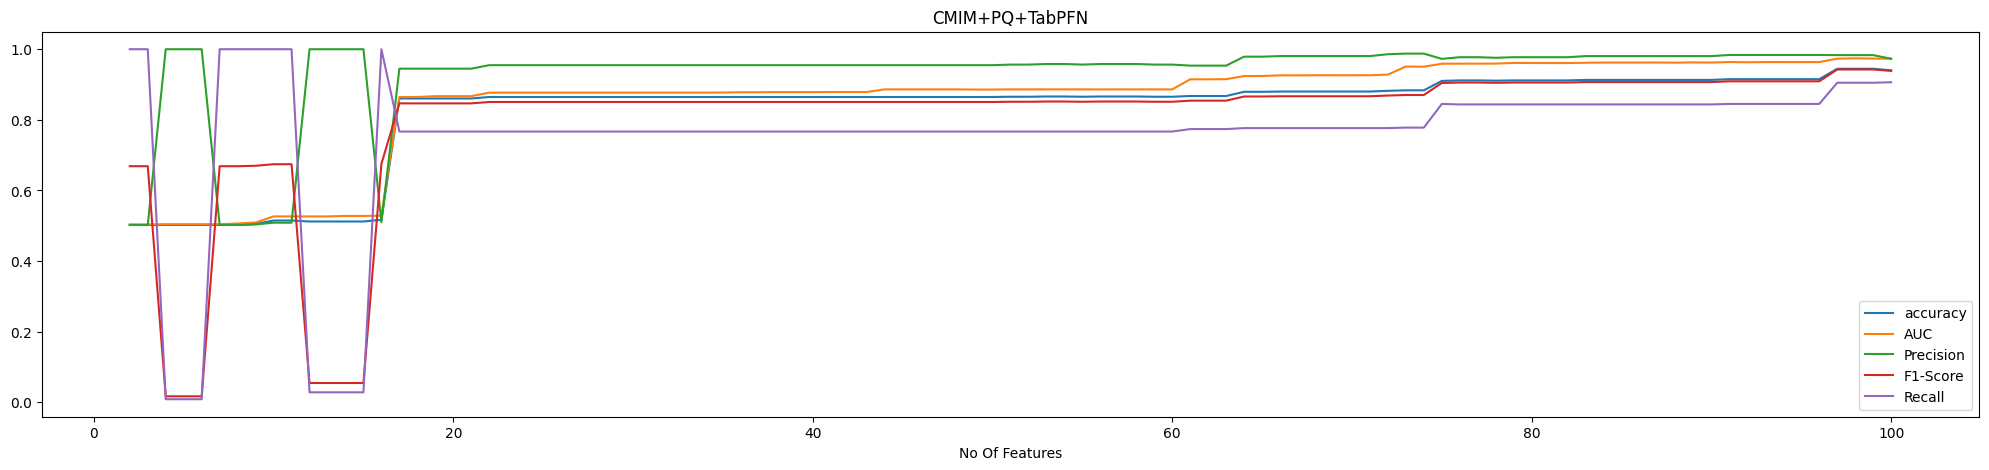

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")
plt.plot(auc_tabPFN, label="AUC")
plt.plot(Precision_tabPFN, label="Precision")
plt.plot(f1Score_tabPFN, label="F1-Score")
plt.plot(Recall_tabPFN , label="Recall")

plt.title("CMIM+PQ+TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

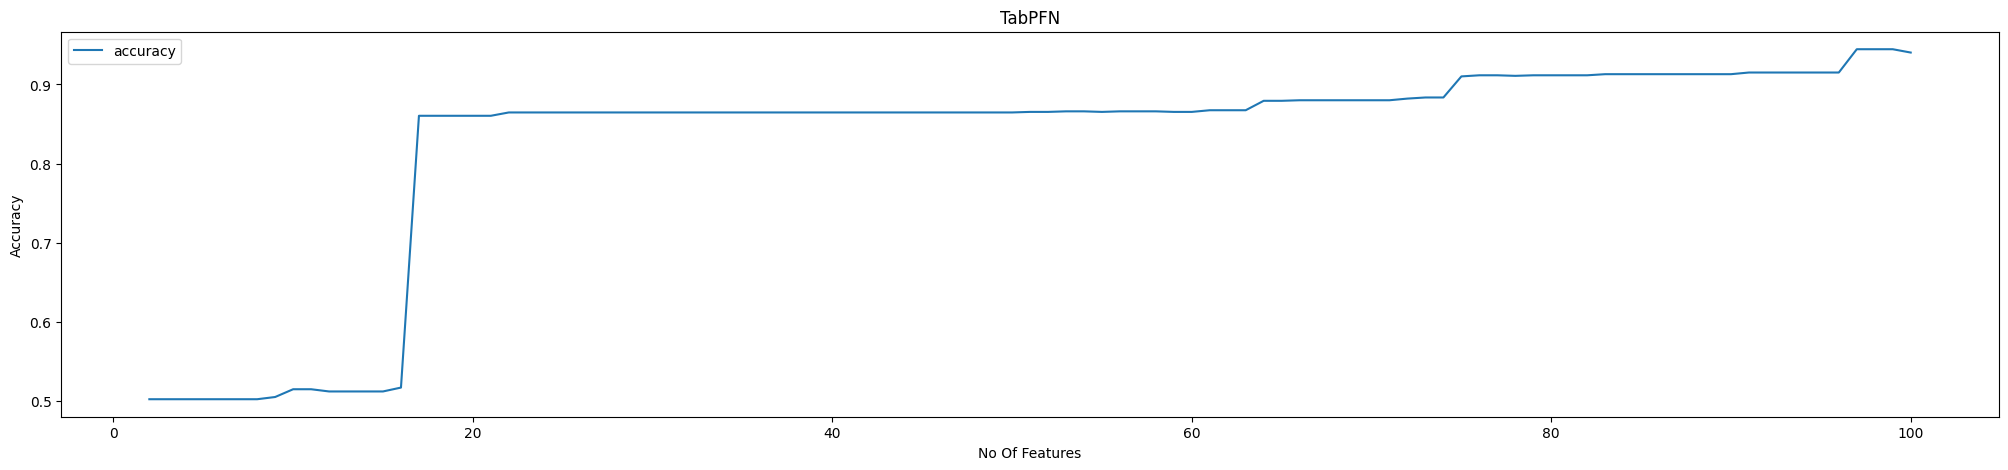

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

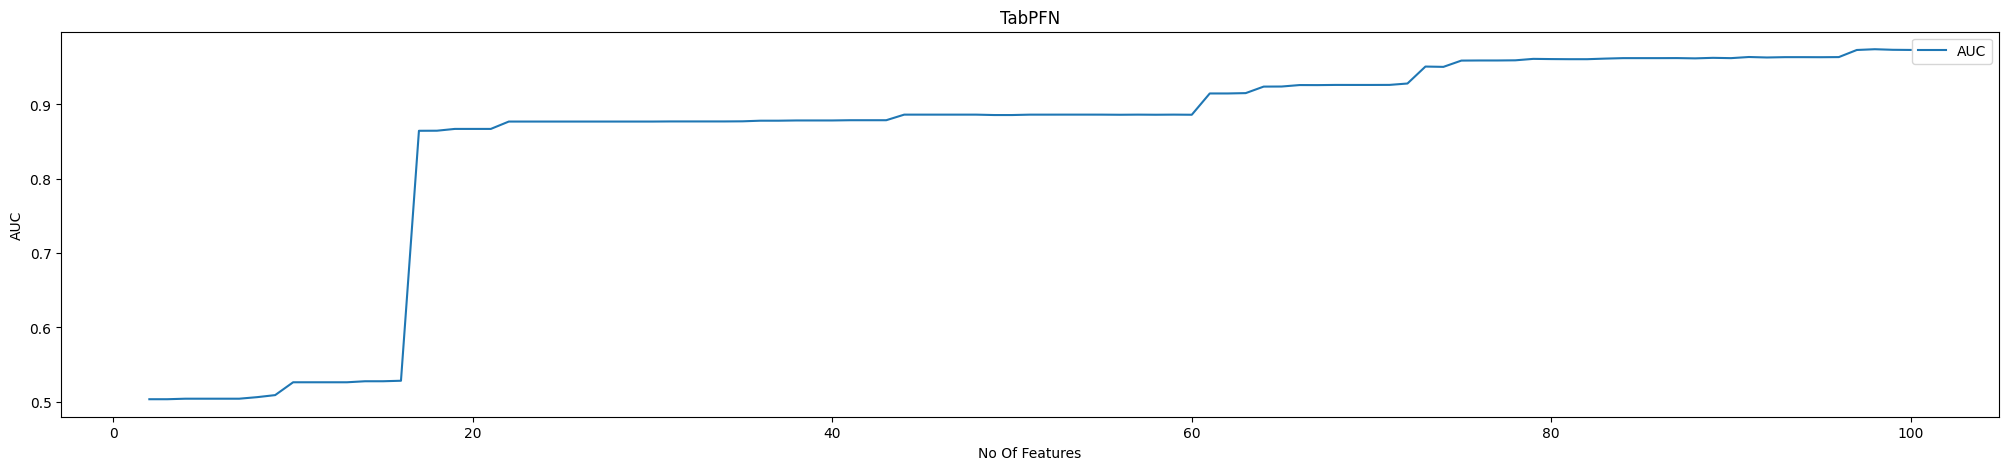

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(auc_tabPFN, label="AUC")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

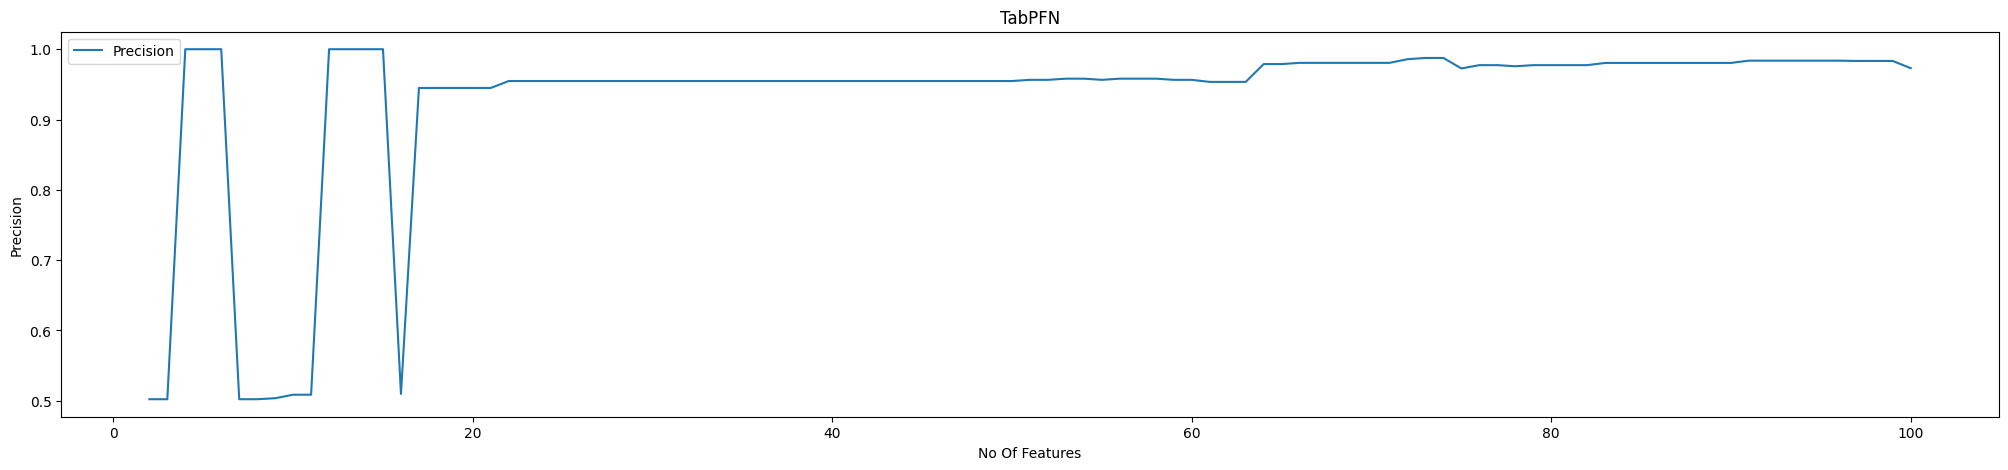

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Precision_tabPFN, label="Precision")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

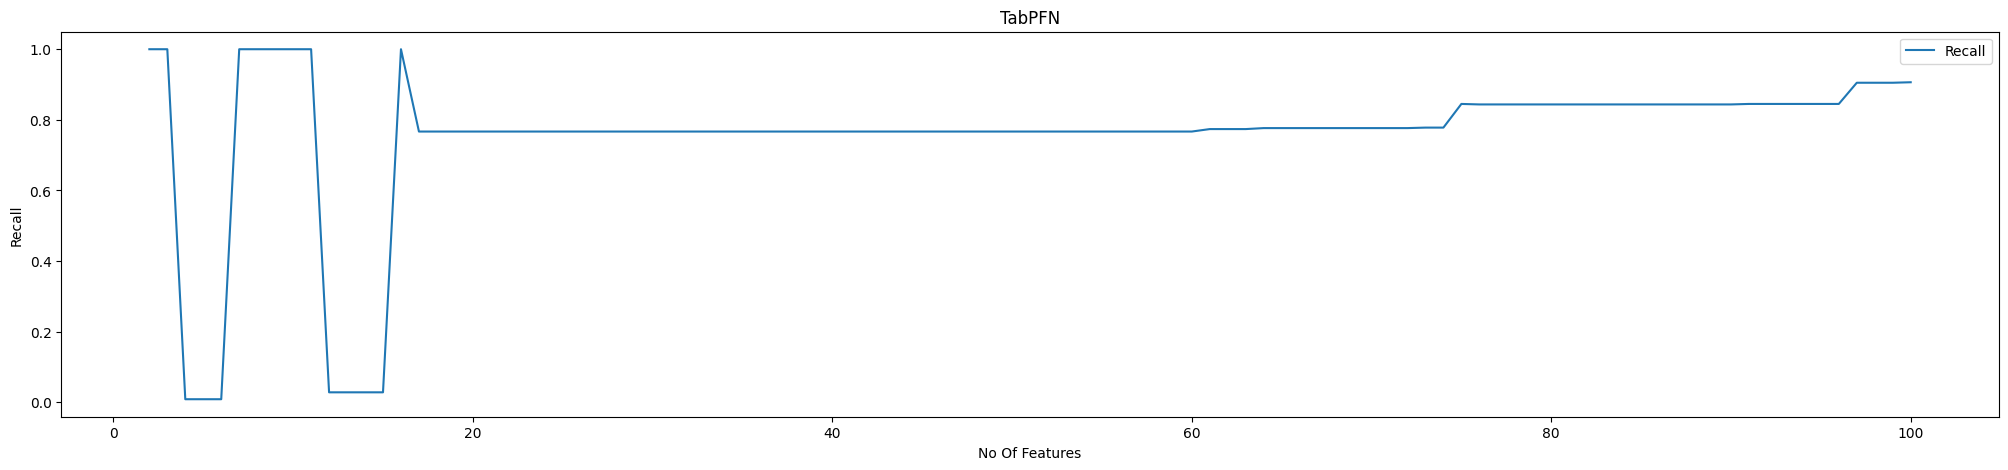

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Recall_tabPFN , label="Recall")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

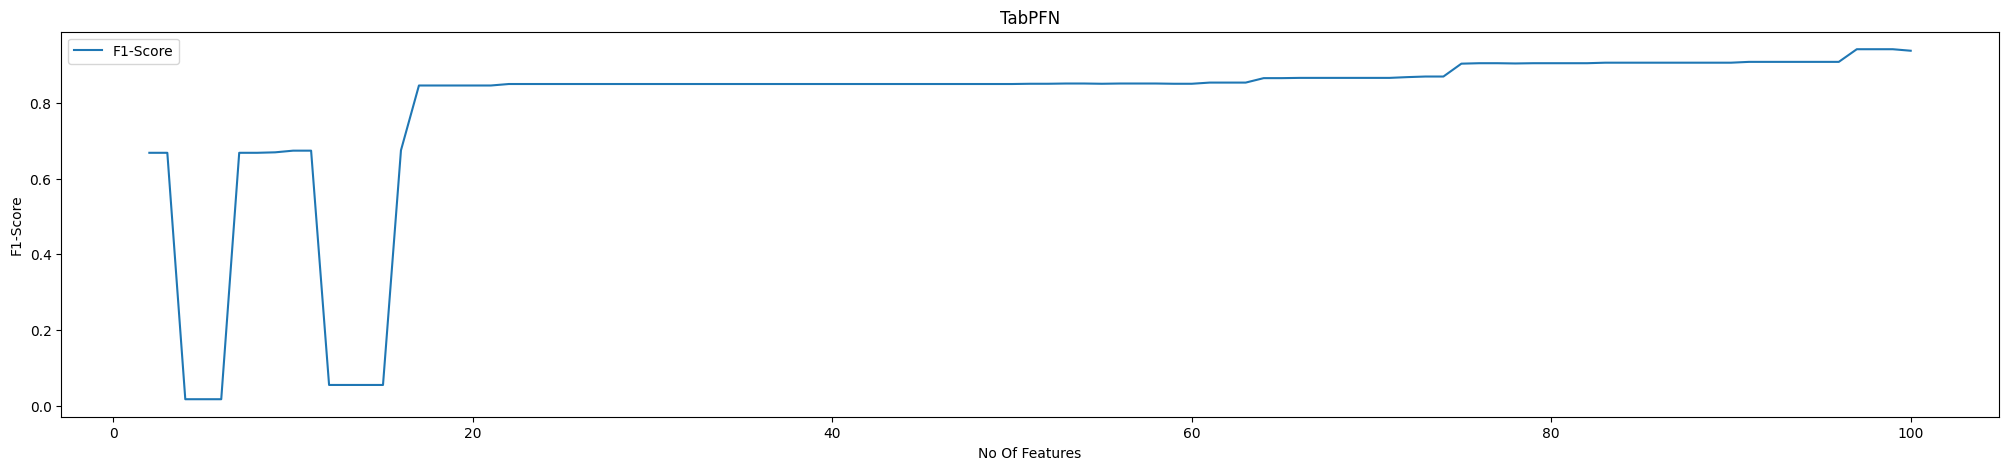

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_tabPFN, label="F1-Score")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()